In [1]:
import numpy as np
import time
import pybullet as p
import pybullet_data
import scipy
import math
import matplotlib as mpl
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from get_robot_iiwa import sim_robot
import pickle
from matplotlib.patches import Ellipse
import mpl_toolkits.mplot3d.art3d as art3d
from gmr import GMM, plot_error_ellipses, plot_error_ellipses_diff_position, plot_error_ellipses_3d_position 
from sklearn.mixture import GaussianMixture

pybullet build time: Oct 14 2023 15:43:53


In [2]:
path_folder = 'data/iiwa_dataset_mice'

joint_pos = np.load(path_folder+'/q_list.npy')

with open(path_folder + '/Joint_X_pos.pkl', 'rb') as f:
    Joint_X_pos = pickle.load(f)

with open(path_folder + '/Jacobians.pkl', 'rb') as f:
    Jacobians = pickle.load(f)

with open(path_folder + '/l.pkl', 'rb') as f:
    l = pickle.load(f)

with open(path_folder + '/v_max.pkl', 'rb') as f:
    v_max = pickle.load(f)

N = joint_pos.shape[0]
print(N)

2157817


In [3]:
X_4 = Joint_X_pos['4']
X_5 = Joint_X_pos['5']
X_6 = Joint_X_pos['6']

X_5_split = np.hsplit(X_5[::200], 3)
X_6_split = np.hsplit(X_6[::200], 3)

l_4 = l['4']
l_5 = l['5']
l_6 = l['6']


v_4 = v_max['4']
v_5 = v_max['5']
v_6 = v_max['6']
print(np.array(X_6).shape)

(2157817, 3)


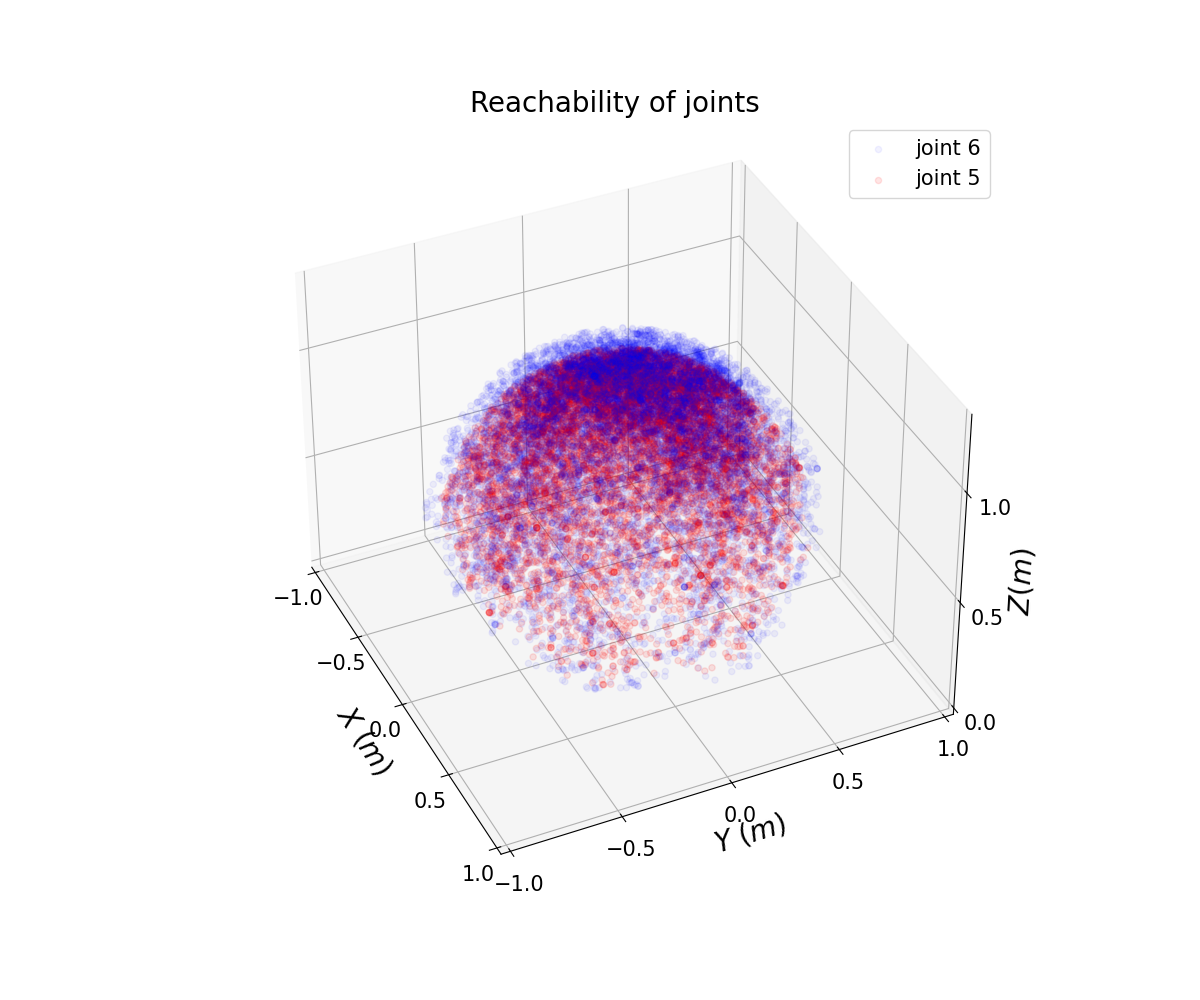

In [4]:
# %matplotlib notebook
%matplotlib widget
fig = plt.figure(figsize=(12,10))
ax = fig.add_subplot(projection='3d')
ax.scatter(X_6_split[0], X_6_split[1], X_6_split[2], color='b', alpha = 0.05)
ax.scatter(X_5_split[0], X_5_split[1], X_5_split[2], color='r', alpha = 0.1)

ax.set_xlabel('$X$ $(m)$', fontsize = 20)
ax.set_ylabel('$Y$ $(m)$', fontsize = 20)
ax.set_zlabel('$Z (m)$', fontsize = 20)
ax.set_xticks([-1, -0.5, 0, 0.5, 1])
ax.set_yticks([-1, -0.5, 0, 0.5, 1])
ax.set_zticks([0, 0.5, 1])
ax.view_init(elev=37, azim=-25)

ax.yaxis._axinfo['label']['space_factor'] = 3.0
ax.xaxis._axinfo['label']['space_factor'] = 3.0

ax.tick_params(axis='both', which='major', labelsize=15)
ax.legend(['joint 6', 'joint 5'], fontsize=15)
ax.set_title("Reachability of joints", fontsize=20)

plt.show()
plt.savefig("joint_reachability", transparent=False, bbox_inches='tight', pad_inches = 0.25, dpi=200)

## Plot a simple heat map

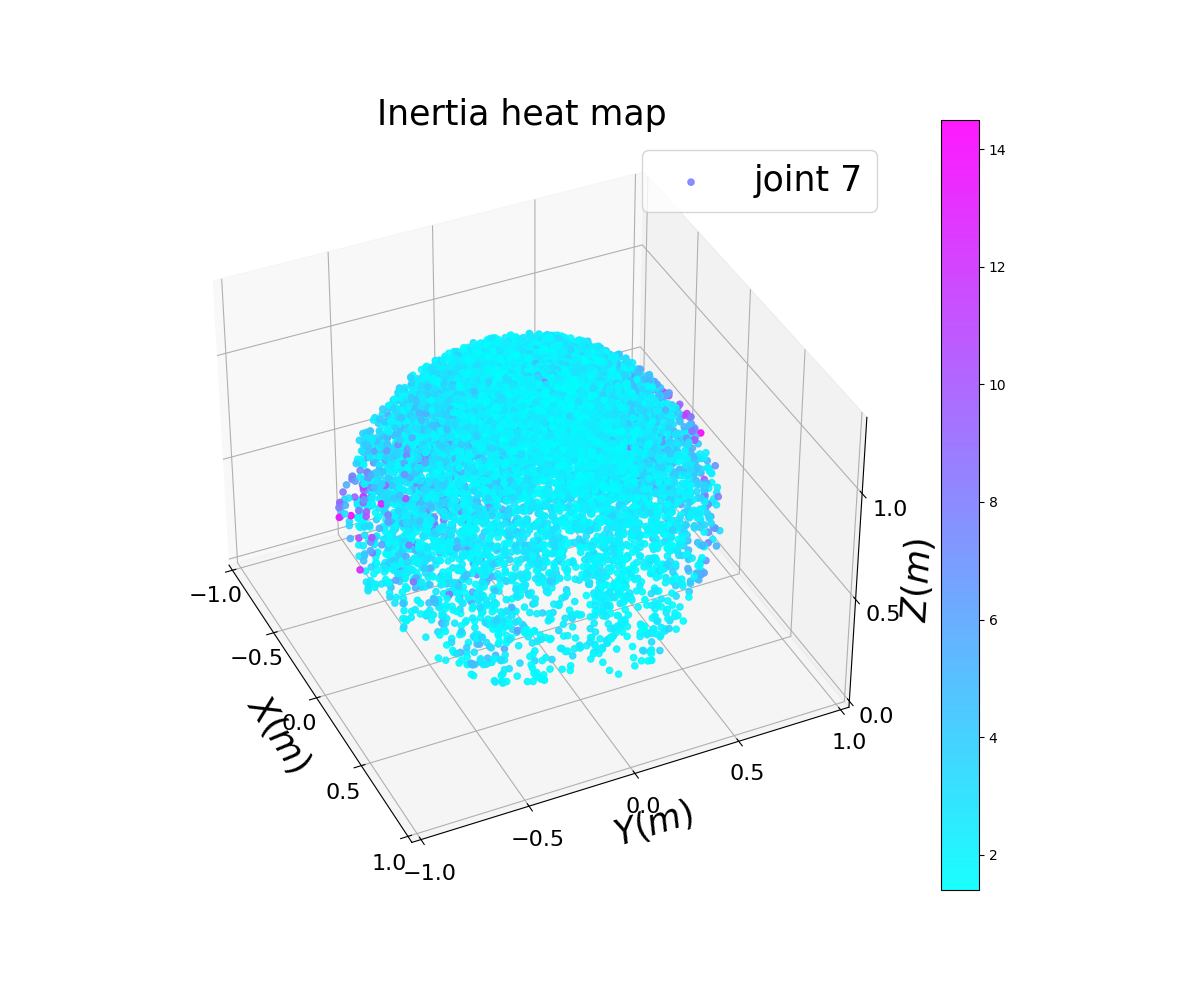

In [4]:
l6 = l_6[::200]
X6 = X_6[::200]
v6 = v_6[::200]

idx = l6 <= 15

l_6_data = l6[idx]
X_6_data = X6[idx, :]

n_data = X_6_data.shape[0]

v_dir = np.array([0, 1, 0])
v_dir_tile = np.tile(v_dir, (n_data, 1))
v_dir_tile = v_dir_tile.astype(float)

v_dir_tile = np.multiply(v_dir_tile, l_6_data[:, np.newaxis])

%matplotlib widget

fig = plt.figure(figsize=(12,10))
ax = fig.add_subplot(111, projection='3d')
img = ax.scatter(X_6_data[:,0], X_6_data[:,1], X_6_data[:,2], c = l_6_data, cmap = 'cool', alpha = 0.9)

ax.set_xlabel('$X (m)$', fontsize = 25)
ax.set_ylabel('$Y (m)$', fontsize = 25)
ax.set_zlabel('$Z (m)$', fontsize = 25)
ax.set_xticks([-1, -0.5, 0, 0.5, 1])
ax.set_yticks([-1, -0.5, 0, 0.5, 1])
ax.set_zticks([0, 0.5, 1])
ax.yaxis._axinfo['label']['space_factor'] = 3.0
ax.view_init(elev=37, azim=-25)
ax.tick_params(axis='both', which='major', labelsize=16)
ax.legend(['joint 7'], fontsize = 25)
ax.set_title("Inertia heat map", fontsize = 25)

fig.colorbar(img)

plt.show()
# plt.savefig("inertia_heat", transparent=False, bbox_inches='tight', pad_inches = 0.25, dpi=200)

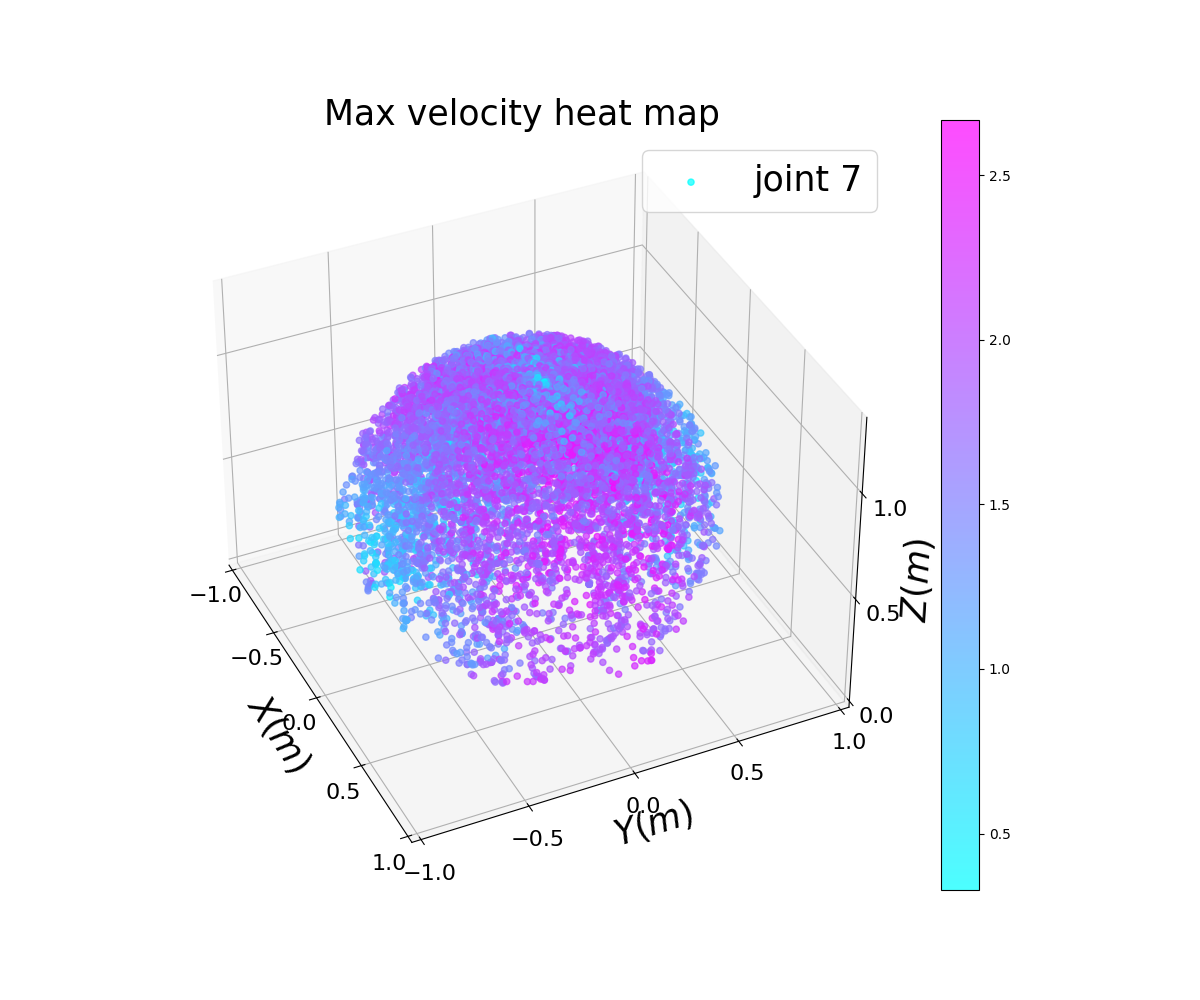

In [5]:
l6 = l_6[::200]
X6 = X_6[::200]
v6 = v_6[::200]

idx = l6 <= 15

l_6_data = l6[idx]
X_6_data = X6[idx, :]
v_6_data = v6[idx]

n_data = X_6_data.shape[0]

v_dir = np.array([0, 1, 0])
v_dir_tile = np.tile(v_dir, (n_data, 1))
v_dir_tile = v_dir_tile.astype(float)

v_dir_tile = np.multiply(v_dir_tile, l_6_data[:, np.newaxis])

%matplotlib widget

fig = plt.figure(figsize=(12,10))
ax = fig.add_subplot(111, projection='3d')
img = ax.scatter(X_6_data[:,0], X_6_data[:,1], X_6_data[:,2], c = v_6_data, cmap = 'cool', alpha = 0.7)

ax.set_xlabel('$X (m)$', fontsize = 25)
ax.set_ylabel('$Y (m)$', fontsize = 25)
ax.set_zlabel('$Z (m)$', fontsize = 25)
ax.set_xticks([-1, -0.5, 0, 0.5, 1])
ax.set_yticks([-1, -0.5, 0, 0.5, 1])
ax.set_zticks([0, 0.5, 1])
ax.yaxis._axinfo['label']['space_factor'] = 3.0
ax.view_init(elev=37, azim=-25)
ax.set_title("Max velocity heat map", fontsize = 25)


ax.tick_params(axis='both', which='major', labelsize=16)
ax.legend(['joint 7'], fontsize = 25)

fig.colorbar(img)

plt.show()
plt.savefig("velocity_heat", transparent=False, bbox_inches='tight', pad_inches = 0.25, dpi=200)


# GMM GMR

In [13]:
## Joint 6 (starting from the number 0)
l6 = l_6[::500]
X6 = X_6[::500]
v6 = v_6[::500]

idx = l6 <= 10

l_6_data = l6[idx]
X_6_data = X6[idx, :]
v_6_data = v6[idx]

print(X_6_data.shape)
print(l_6_data.shape)
print(v_6_data.shape)

n_6_data = X_6_data.shape[0]


## Joint 5 (starting from the number 0)
l5 = l_5[::500]
X5 = X_5[::500]
v5 = v_5[::500]

idx = l5 <= 20

l_5_data = l5[idx]
X_5_data = X5[idx, :]
v_5_data = v5[idx]

print(X_5_data.shape)
print(l_5_data.shape)
print(v_5_data.shape)

n_5_data = X_5_data.shape[0]

##########

l4 = l_4[::500]
X4 = X_4[::500]
v4 = v_4[::500]

idx = l4 <= 20

l_4_data = l4[idx]
X_4_data = X4[idx, :]
v_4_data = v4[idx]



(4303, 3)
(4303,)
(4303,)
(4298, 3)
(4298,)
(4298,)


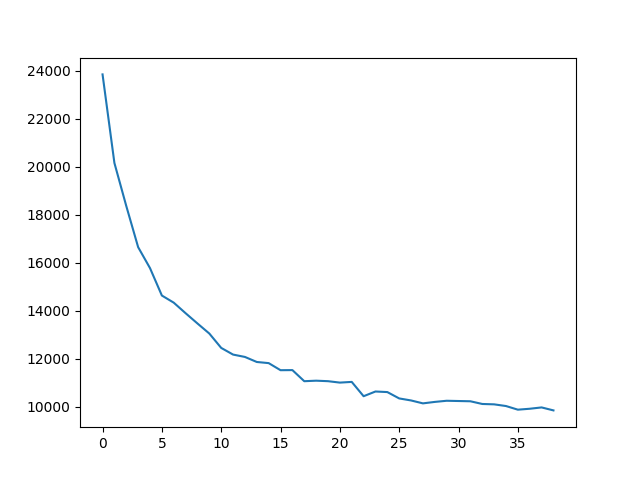

In [14]:
input_6 = np.concatenate((X_6_data, l_6_data.reshape(-1, 1), v_6_data.reshape(-1, 1)), axis=1)
input_5 = np.concatenate((X_5_data, l_5_data.reshape(-1, 1), v_5_data.reshape(-1, 1)), axis=1)

# input_lv_6 = np.concatenate(( l_6_data.reshape(-1, 1), v_6_data.reshape(-1, 1)), axis=1)
# input_lv_5 = np.concatenate(( l_5_data.reshape(-1, 1), v_5_data.reshape(-1, 1)), axis=1)

# gmm_lv = GMM(n_components=3, random_state = 0)
# gmm_lv.from_samples(input_lv, init_params="kmeans++")

# gmm_full_6 = GMM(n_components=5, random_state = 0)
# gmm_full_6.from_samples(input_6, init_params="kmeans++")

# gmm_full_5 = GMM(n_components=5, random_state = 0)
# gmm_full_5.from_samples(input_5, init_params="kmeans++")
aic, bic = [], []

for k in range(1, 40):
    gmm_sk_6 = GaussianMixture(n_components=k, random_state=0, init_params='k-means++').fit(input_6)
    aic.append(gmm_sk_6.aic(input_6))
    bic.append(gmm_sk_6.bic(input_6))

# print(aic)
# print(bic)

plt.figure()
plt.plot(aic)

In [15]:
input_6 = np.concatenate((X_6_data, l_6_data.reshape(-1, 1), v_6_data.reshape(-1, 1)), axis=1)
input_5 = np.concatenate((X_5_data, l_5_data.reshape(-1, 1), v_5_data.reshape(-1, 1)), axis=1)

# input_lv_6 = np.concatenate(( l_6_data.reshape(-1, 1), v_6_data.reshape(-1, 1)), axis=1)
# input_lv_5 = np.concatenate(( l_5_data.reshape(-1, 1), v_5_data.reshape(-1, 1)), axis=1)

# gmm_lv = GMM(n_components=3, random_state = 0)
# gmm_lv.from_samples(input_lv, init_params="kmeans++")

gmm_full_6 = GMM(n_components=5, random_state = 0)
gmm_full_6.from_samples(input_6, init_params="kmeans++")

gmm_full_5 = GMM(n_components=5, random_state = 0)
gmm_full_5.from_samples(input_5, init_params="kmeans++")

gmm_full_6.means

    

# given_position_test = np.array([0.5, 0.3, 0.3])
# gmm_lv_cond_test = gmm_full.condition(np.array([0,1,2]), given_position_test)


array([[ 0.02758063,  0.02120839,  1.15663478,  2.16992644,  1.77515592],
       [ 0.36851199, -0.10689216,  0.79407575,  2.41559009,  1.77322522],
       [-0.33066614, -0.15851781,  0.88112493,  3.48884137,  1.68792369],
       [-0.31521229, -0.04214629,  0.76123654,  1.93005705,  1.72387905],
       [-0.00475931,  0.48652905,  0.84595798,  3.69573336,  1.31596348]])

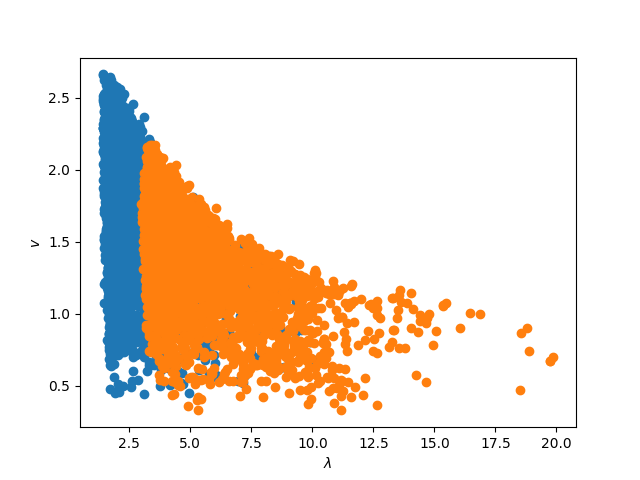

In [16]:
%matplotlib widget

plt.figure()
plt.scatter(l_6_data, v_6_data)
plt.scatter(l_5_data, v_5_data)
plt.xlabel('$\lambda$')
plt.ylabel('$v$')
# plt.scatter(l_4_data, v_4_data)
# plot_error_ellipses(plt.gca(), gmm_lv, colors = ['r', 'g', 'b'])
plt.show()

[0.32387398 0.14494508]
[0.32387398 0.14494508]
[0.32387398 0.14494508]
[0.32387398 0.14494508]
[0.32387398 0.14494508]
[0.32387398 0.14494508]
[0.32387398 0.14494508]
[0.32387398 0.14494508]


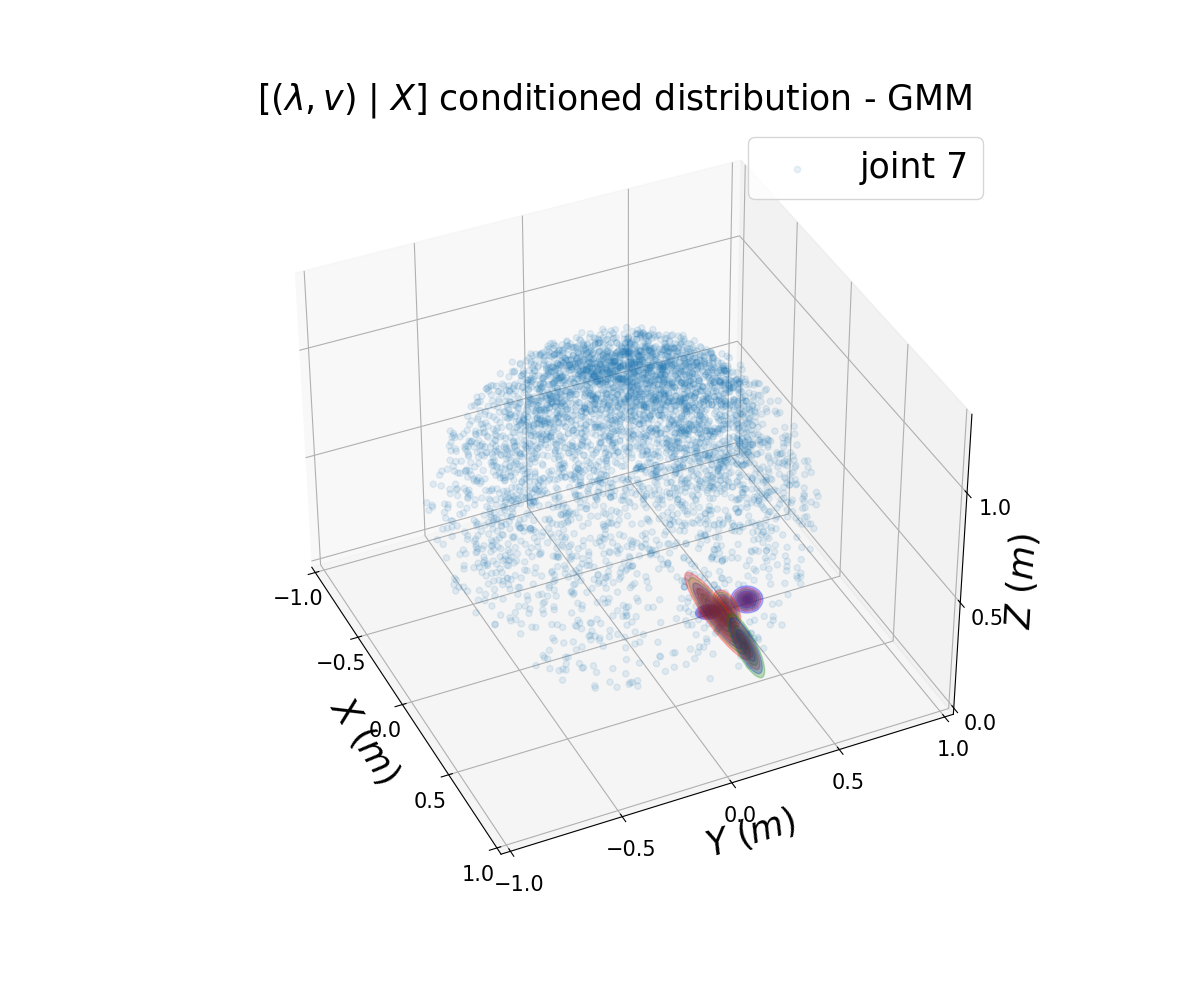

In [20]:
%matplotlib widget

fig = plt.figure(figsize=(12,10))
ax = fig.add_subplot(111, projection='3d')

# img = ax.scatter(X_6_data[:,0], X_6_data[:,1], X_6_data[:,2], c = l_6_data, cmap = 'cool', alpha = 1)
img = ax.scatter(X_6_data[:,0], X_6_data[:,1], X_6_data[:,2], alpha = 0.1)

ax.set_xlabel('$X$ $(m)$', fontsize = 25)
ax.set_ylabel('$Y$ $(m)$', fontsize = 25)
ax.set_zlabel('$Z$ $(m)$', fontsize = 25)
ax.view_init(elev=37, azim=-25)
ax.legend(['joint 7'], fontsize = 25)
ax.set_title("$[(\lambda, v)$ $|$ $X]$ conditioned distribution - GMM", fontsize = 25)
ax.yaxis._axinfo['label']['space_factor'] = 3.0
ax.xaxis._axinfo['label']['space_factor'] = 3.0

ax.tick_params(axis='both', which='major', labelsize=15)
ax.set_xticks([-1, -0.5, 0, 0.5, 1])
ax.set_yticks([-1, -0.5, 0, 0.5, 1])
ax.set_zticks([0, 0.5, 1])

# fig.colorbar(img)

given_position = np.array([0.5, 0.4, 0.2])
# Plotting a few different GMMs
# for i in range(1):
    # given_position = X_6_data[i*50,:]
    # print(given_position)
gmm_lv_x_6 = gmm_full_6.condition(np.array([0,1,2]), given_position)
# gmm_lv_x_6.means
plot_error_ellipses_3d_position(plt.gca(), gmm_lv_x_6, given_position, colors = ['r', 'g', 'b'])
plt.show()
plt.savefig("conditional_lv", transparent=False, bbox_inches='tight', pad_inches = 0.25, dpi=200)


# Experiment setup

In [13]:
## Store the GMMs

pickle.dump(gmm_full_6, open("gmm_6", "wb"))
pickle.dump(gmm_full_5, open("gmm_5", "wb"))


In [12]:
X_Obj = np.array([0.5, 0.4, 0.2])
X_Obj = np.array([0.5, 0.2, 0.2])

# gmm_lv_x_6 = gmm_full_6.condition(np.array([0,1,2]), X_obj)
# gmm_lv_x_5 = gmm_full_5.condition(np.array([0,1,2]), X_obj)

pred_6 = gmm_full_6.predict(np.array([0,1,2]), X_Obj.reshape(-1,1).T)
pred_5 = gmm_full_5.predict(np.array([0,1,2]), X_Obj.reshape(-1,1).T)

print(pred_6)
print(pred_5)
# Y = gmm.predict(np.array([0]), X_test[:, np.newaxis])

[[2.297508   1.67380441]]
[[3.78887383 1.50149693]]
